In [2]:
# Verify that all dependencies work
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ Libraries sucessfully imported")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

✓ Libraries sucessfully imported
Pandas version: 2.3.3
Numpy version: 2.1.3


In [4]:
# Load processed sample data with features
from pathlib import Path

# Load the data
data_path = Path("../../data/processed/sample_with_features.parquet")
df = pd.read_parquet(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (18850, 61)

Columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'has_event_1', 'has_event_2', 'has_any_event', 'event_type_1_encoded', 'price_change', 'price_change_pct', 'price_momentum', 'price_vs_ma_7', 'price_vs_ma_28', 'price_rank_in_category', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_std_7', 'sales_rolling_min_7', 'sales_rolling_max_7', 'sales_rolling_mean_28', 'sales_rolling_std_28', 'sales_rolling_min_28', 'sales_rolling_max_28', 'store_avg_sales', 'cat_avg_sales', 'dept_avg_sales', 'state_avg_sales', 'item_share_of_cat', 'item_share_of_store']

Fi

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,sales_rolling_mean_28,sales_rolling_std_28,sales_rolling_min_28,sales_rolling_max_28,store_avg_sales,cat_avg_sales,dept_avg_sales,state_avg_sales,item_share_of_cat,item_share_of_store
0,FOODS_1_049_TX_2_validation,FOODS_1_049,FOODS_1,FOODS,TX_2,TX,d_1,0,2011-01-29,11101,...,NaN,NaN,NaN,NaN,0.0,0.4,0.000000,0.0,0.000000,0.000000
1,FOODS_1_049_TX_2_validation,FOODS_1_049,FOODS_1,FOODS,TX_2,TX,d_2,1,2011-01-30,11101,...,0.000000,NaN,0.0,0.0,2.0,1.1,0.333333,2.0,0.909090,0.500000
2,FOODS_1_049_TX_2_validation,FOODS_1_049,FOODS_1,FOODS,TX_2,TX,d_3,0,2011-01-31,11101,...,0.500000,0.707107,0.0,1.0,0.0,0.3,0.000000,0.0,0.000000,0.000000
3,FOODS_1_049_TX_2_validation,FOODS_1_049,FOODS_1,FOODS,TX_2,TX,d_4,0,2011-02-01,11101,...,0.333333,0.577350,0.0,1.0,0.5,1.4,0.000000,0.5,0.000000,0.000000
4,FOODS_1_049_TX_2_validation,FOODS_1_049,FOODS_1,FOODS,TX_2,TX,d_5,4,2011-02-02,11101,...,0.250000,0.500000,0.0,1.0,2.5,1.0,1.333333,2.5,3.999996,1.599999


In [5]:
# Basic dataset info
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"Number of days: {df['date'].nunique()}")
print(f"Number of products: {df['id'].nunique()}")
print(f"Number of stores: {df['store_id'].nunique()}")
print(f"Categories: {df['cat_id'].unique()}")

print("\n" + "="*60)
print("SALES STATISTICS")
print("="*60)
print(df['sales'].describe())

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing)
else:
    print("No missing values in core columns")

DATASET OVERVIEW

Date range: 2011-01-29 00:00:00 to 2016-03-27 00:00:00
Number of days: 1885
Number of products: 10
Number of stores: 5
Categories: ['FOODS']

SALES STATISTICS
count    18850.000000
mean         0.582706
std          1.216052
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         25.000000
Name: sales, dtype: float64

MISSING VALUES
sales_lag_28             280
sales_lag_14             140
sales_lag_7               70
price_momentum            20
sales_rolling_std_7       20
sales_rolling_std_28      20
price_change              10
price_change_pct          10
sales_rolling_mean_7      10
sales_rolling_min_7       10
sales_rolling_max_7       10
sales_rolling_mean_28     10
sales_rolling_min_28      10
sales_rolling_max_28      10
dtype: int64


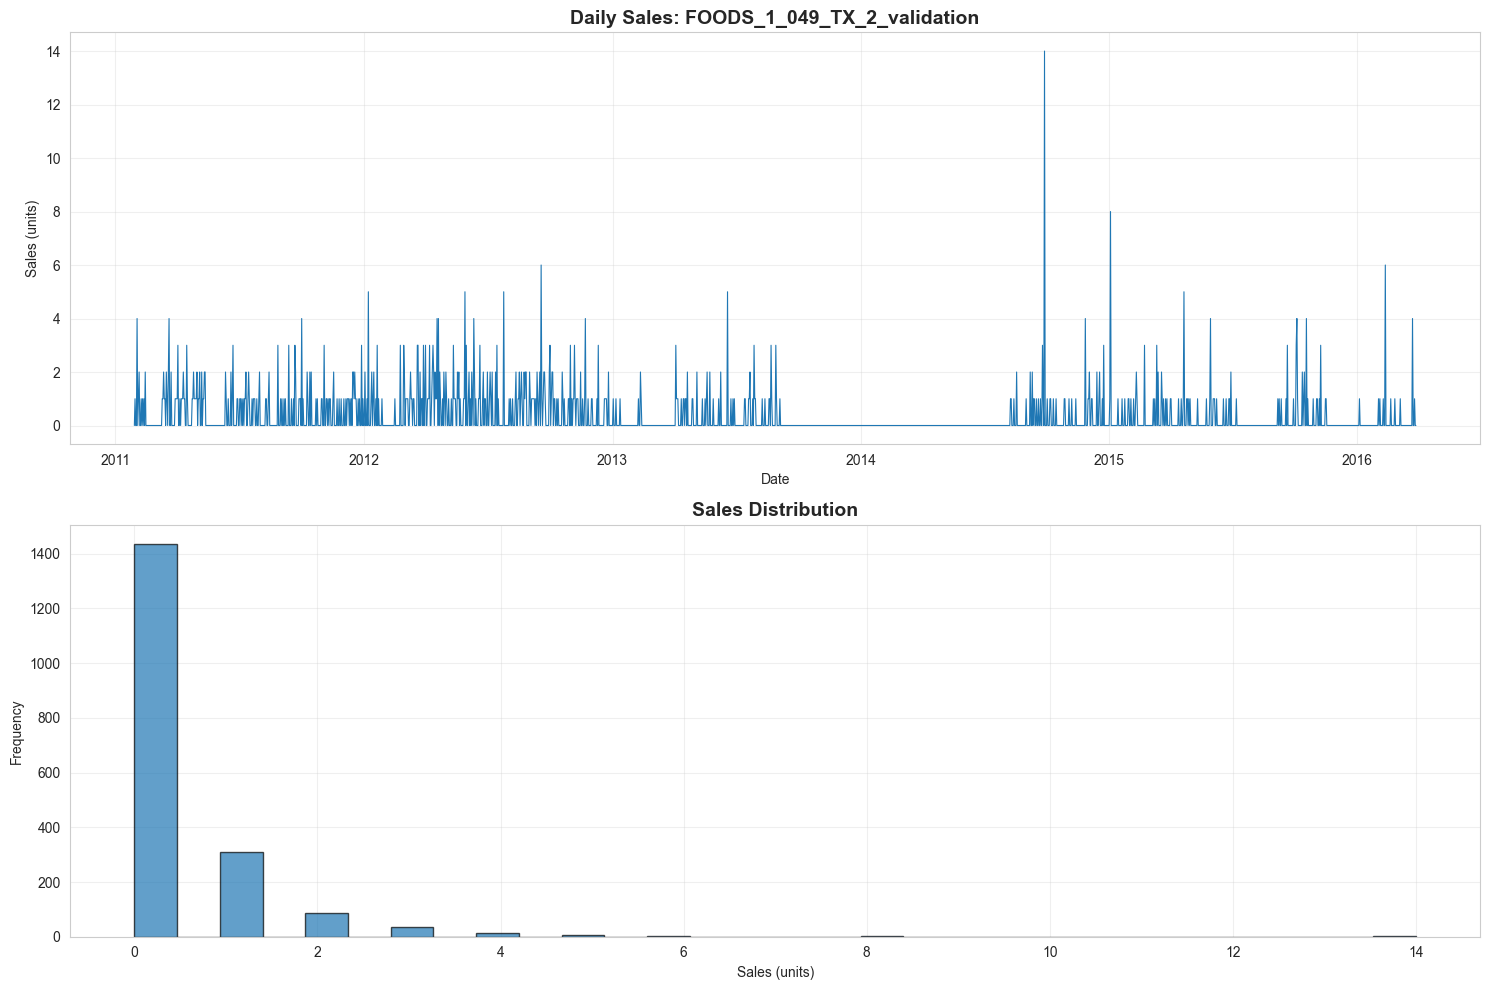

Product: FOODS_1_049_TX_2_validation
Store: TX_2
Category: FOODS


In [6]:
# Visualize sales over time for one product
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

# Select one product to visualize
product_id = df['id'].iloc[0]
product_data = df[df['id'] == product_id].sort_values('date')

# Plot sales over time
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# 1. Daily sales
axes[0].plot(product_data['date'], product_data['sales'], linewidth=0.8)
axes[0].set_title(f'Daily Sales: {product_id}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales (units)')
axes[0].grid(True, alpha=0.3)

# 2. Sales distribution
axes[1].hist(product_data['sales'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_title('Sales Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sales (units)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Product: {product_id}")
print(f"Store: {product_data['store_id'].iloc[0]}")
print(f"Category: {product_data['cat_id'].iloc[0]}")

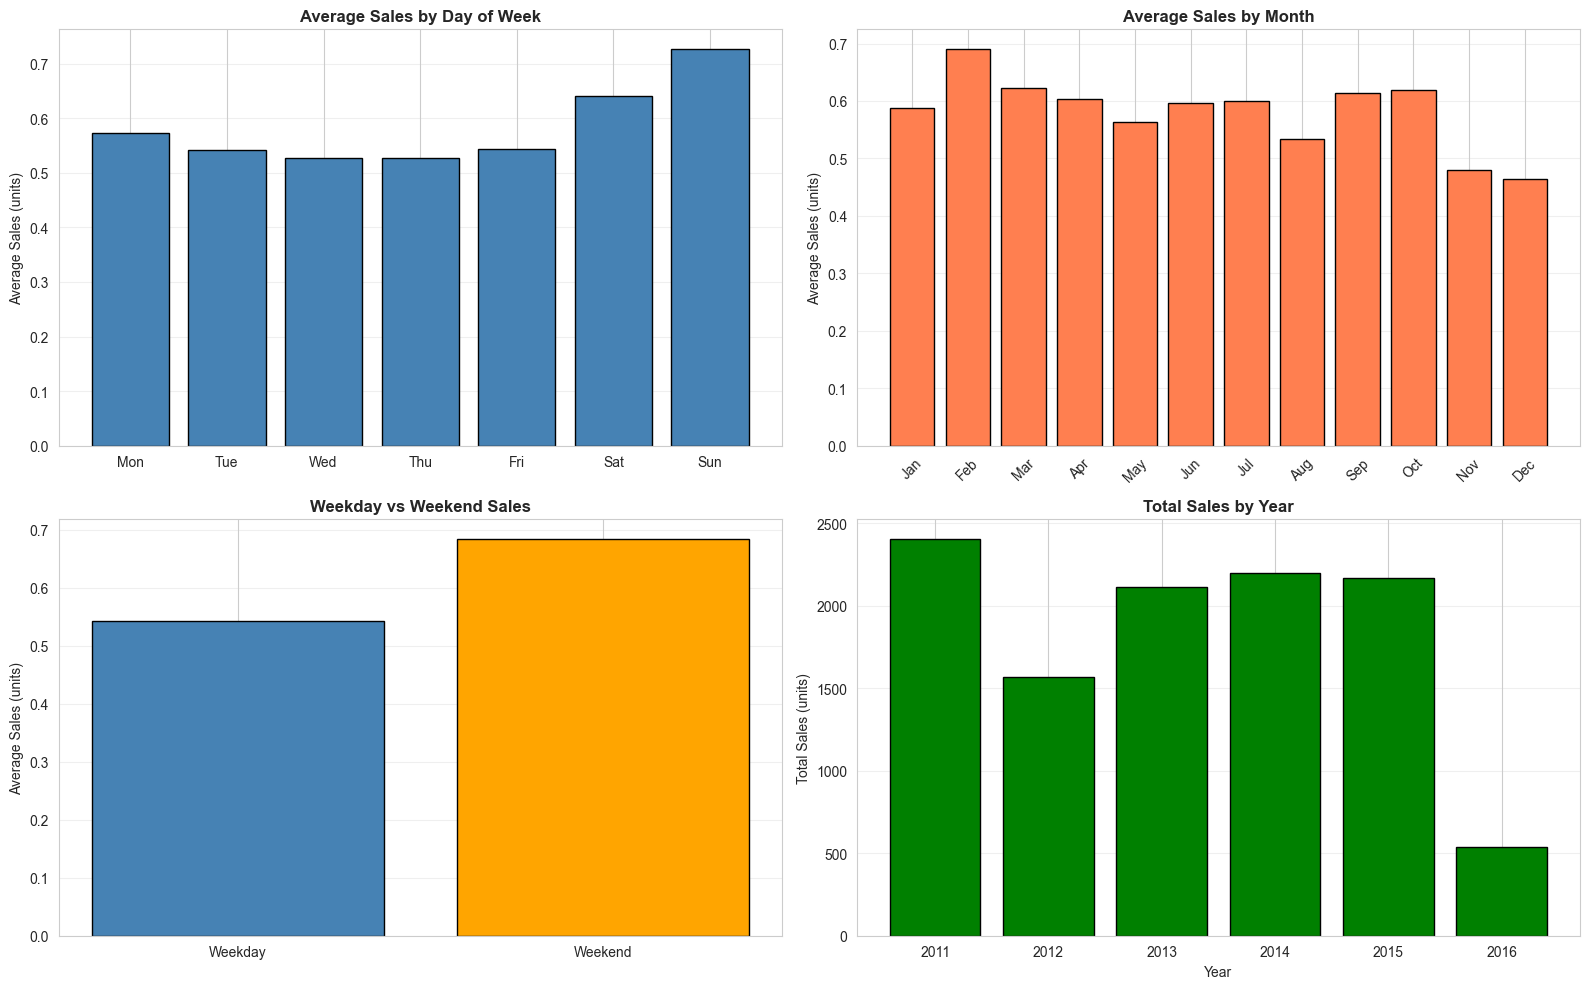


SEASONALITY INSIGHTS
Best day of week: Sun (avg: 0.73 units)
Worst day of week: Thu (avg: 0.53 units)

Best month: Feb (avg: 0.69 units)
Worst month: Dec (avg: 0.46 units)

Weekday avg: 0.54 units
Weekend avg: 0.68 units


In [7]:
# ============================================================
# SEASONALITY ANALYSIS
# ============================================================

# Aggregate daily sales across all products
daily_agg = df.groupby('date').agg({
    'sales': 'sum',
    'day_of_week': 'first',
    'month': 'first',
    'is_weekend': 'first'
}).reset_index()

# Day of week pattern
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Sales by day of week
dow_sales = df.groupby('day_of_week')['sales'].mean()
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0, 0].bar(range(7), dow_sales.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xticks(range(7))
axes[0, 0].set_xticklabels(dow_names)
axes[0, 0].set_title('Average Sales by Day of Week', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Average Sales (units)')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Sales by month
month_sales = df.groupby('month')['sales'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0, 1].bar(range(1, 13), month_sales.values, color='coral', edgecolor='black')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_names, rotation=45)
axes[0, 1].set_title('Average Sales by Month', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Average Sales (units)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Weekday vs Weekend
weekend_comparison = df.groupby('is_weekend')['sales'].mean()
axes[1, 0].bar(['Weekday', 'Weekend'], weekend_comparison.values, 
               color=['steelblue', 'orange'], edgecolor='black')
axes[1, 0].set_title('Weekday vs Weekend Sales', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Average Sales (units)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Sales distribution by year
df['year'] = df['date'].dt.year
year_sales = df.groupby('year')['sales'].sum()
axes[1, 1].bar(year_sales.index, year_sales.values, color='green', edgecolor='black')
axes[1, 1].set_title('Total Sales by Year', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Total Sales (units)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SEASONALITY INSIGHTS")
print("="*60)
print(f"Best day of week: {dow_names[dow_sales.idxmax()]} (avg: {dow_sales.max():.2f} units)")
print(f"Worst day of week: {dow_names[dow_sales.idxmin()]} (avg: {dow_sales.min():.2f} units)")
print(f"\nBest month: {month_names[month_sales.idxmax()-1]} (avg: {month_sales.max():.2f} units)")
print(f"Worst month: {month_names[month_sales.idxmin()-1]} (avg: {month_sales.min():.2f} units)")
print(f"\nWeekday avg: {weekend_comparison[0]:.2f} units")
print(f"Weekend avg: {weekend_comparison[1]:.2f} units")

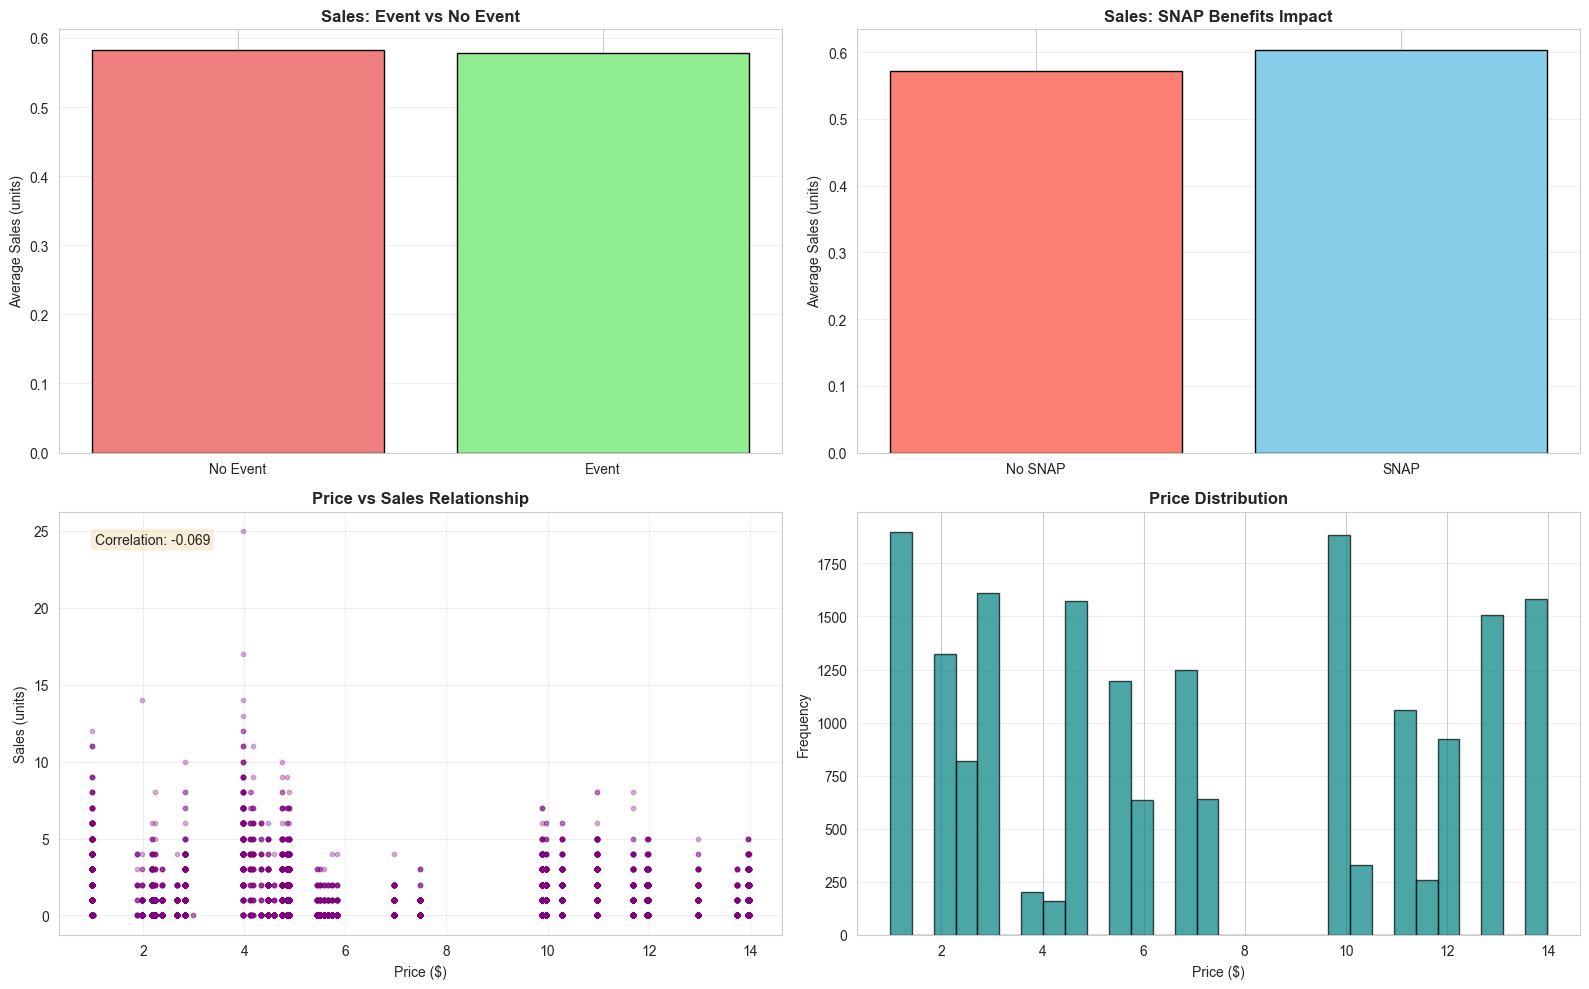


EVENT & PRICE INSIGHTS
Sales without events: 0.583 units
Sales with events: 0.578 units
Event lift: -0.9%

Sales without SNAP: 0.572 units
Sales with SNAP: 0.604 units
SNAP lift: 5.5%

Price-Sales correlation: -0.069
Average price: $7.08
Price range: $0.98 - $13.98


In [8]:
# ============================================================
# EVENT & PRICE IMPACT ANALYSIS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Sales with vs without events
event_impact = df.groupby('has_any_event')['sales'].mean()
axes[0, 0].bar(['No Event', 'Event'], event_impact.values, 
               color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[0, 0].set_title('Sales: Event vs No Event', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Average Sales (units)')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. SNAP benefits impact
snap_cols = [col for col in df.columns if col.startswith('snap_')]
if snap_cols:
    snap_impact = df.groupby(snap_cols[0])['sales'].mean()
    axes[0, 1].bar(['No SNAP', 'SNAP'], snap_impact.values,
                   color=['salmon', 'skyblue'], edgecolor='black')
    axes[0, 1].set_title('Sales: SNAP Benefits Impact', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Average Sales (units)')
    axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Price vs Sales correlation
# Remove NaN values for price analysis
price_data = df[df['sell_price'].notna() & df['sales'].notna()]
if len(price_data) > 0:
    axes[1, 0].scatter(price_data['sell_price'], price_data['sales'], 
                       alpha=0.3, s=10, color='purple')
    axes[1, 0].set_title('Price vs Sales Relationship', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Price ($)')
    axes[1, 0].set_ylabel('Sales (units)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Calculate correlation
    correlation = price_data[['sell_price', 'sales']].corr().iloc[0, 1]
    axes[1, 0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                    transform=axes[1, 0].transAxes, fontsize=10,
                    verticalalignment='top', bbox=dict(boxstyle='round', 
                    facecolor='wheat', alpha=0.5))

# 4. Price distribution
if 'sell_price' in df.columns:
    price_clean = df['sell_price'].dropna()
    axes[1, 1].hist(price_clean, bins=30, color='teal', edgecolor='black', alpha=0.7)
    axes[1, 1].set_title('Price Distribution', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Price ($)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print insights
print("\n" + "="*60)
print("EVENT & PRICE INSIGHTS")
print("="*60)
print(f"Sales without events: {event_impact[0]:.3f} units")
print(f"Sales with events: {event_impact[1]:.3f} units")
print(f"Event lift: {((event_impact[1] / event_impact[0] - 1) * 100):.1f}%")

if snap_cols:
    print(f"\nSales without SNAP: {snap_impact[0]:.3f} units")
    print(f"Sales with SNAP: {snap_impact[1]:.3f} units")
    print(f"SNAP lift: {((snap_impact[1] / snap_impact[0] - 1) * 100):.1f}%")

if len(price_data) > 0:
    print(f"\nPrice-Sales correlation: {correlation:.3f}")
    print(f"Average price: ${price_clean.mean():.2f}")
    print(f"Price range: ${price_clean.min():.2f} - ${price_clean.max():.2f}")

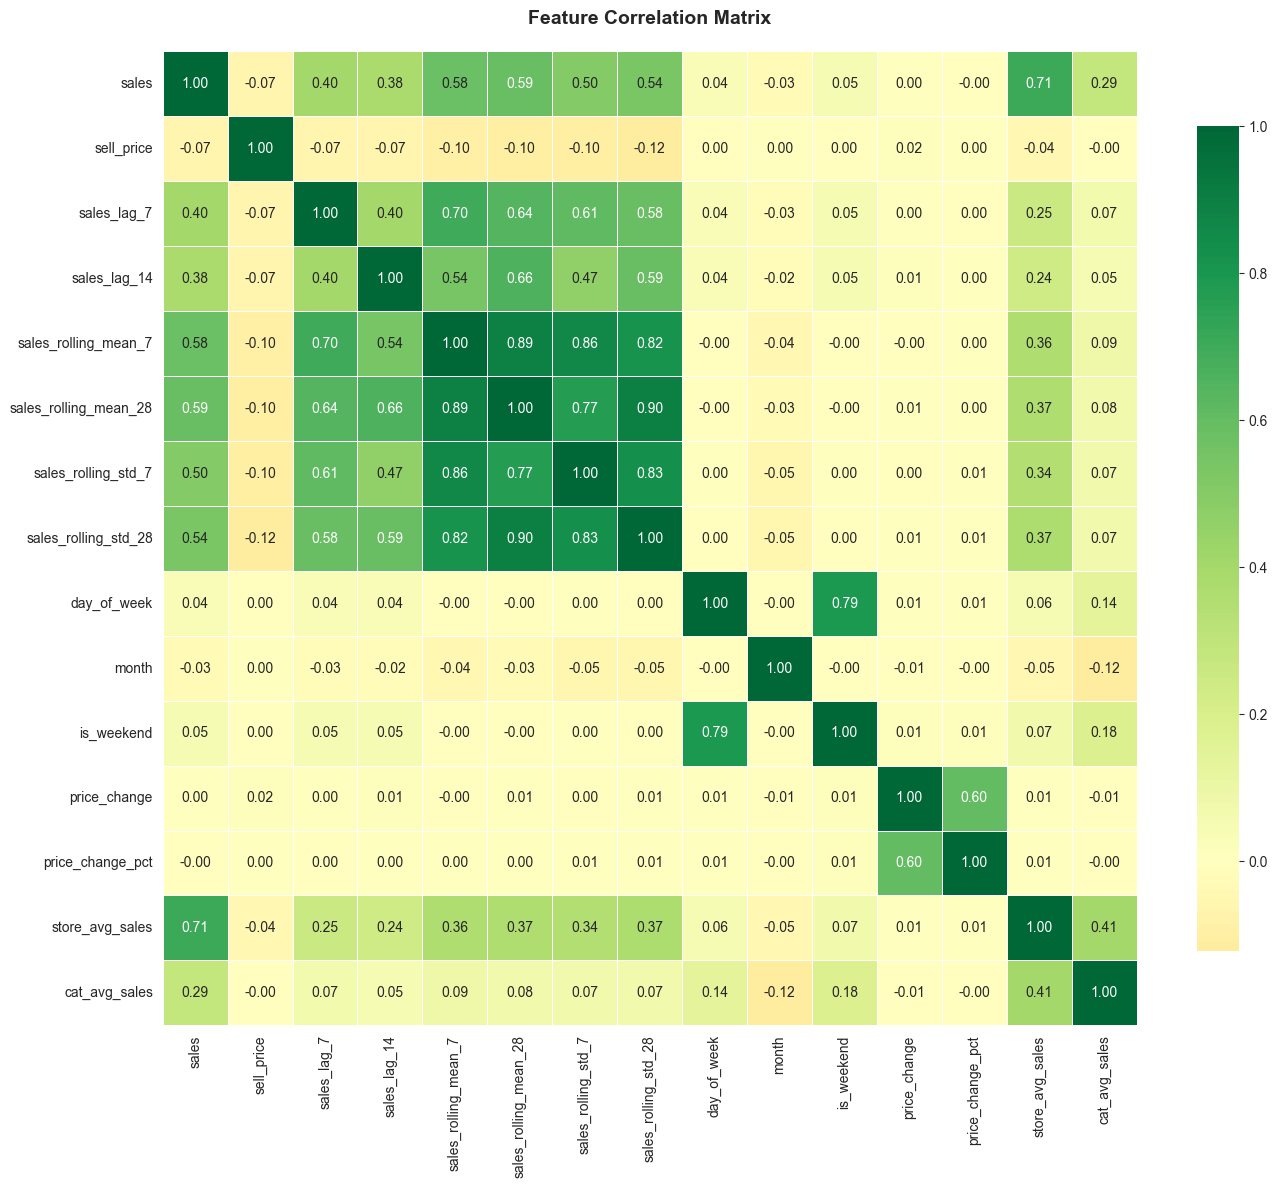


TOP CORRELATIONS WITH SALES

Positive correlations:
sales                    1.000000
store_avg_sales          0.708946
sales_rolling_mean_28    0.588201
sales_rolling_mean_7     0.580254
sales_rolling_std_28     0.536314
sales_rolling_std_7      0.502141
sales_lag_7              0.402145
sales_lag_14             0.378282
cat_avg_sales            0.288337
is_weekend               0.052434
Name: sales, dtype: float64

Negative correlations:
price_change_pct   -0.003749
month              -0.033341
sell_price         -0.068672
Name: sales, dtype: float64

FEATURE IMPORTANCE RANKING
 1. store_avg_sales                : 0.709
 2. sales_rolling_mean_28          : 0.588
 3. sales_rolling_mean_7           : 0.580
 4. sales_rolling_std_28           : 0.536
 5. sales_rolling_std_7            : 0.502
 6. sales_lag_7                    : 0.402
 7. sales_lag_14                   : 0.378
 8. cat_avg_sales                  : 0.288
 9. sell_price                     : 0.069
10. is_weekend           

In [9]:
# ============================================================
# FEATURE CORRELATION ANALYSIS
# ============================================================

# Select numeric features related to sales
feature_cols = [
    'sales', 'sell_price', 
    'sales_lag_7', 'sales_lag_14', 
    'sales_rolling_mean_7', 'sales_rolling_mean_28',
    'sales_rolling_std_7', 'sales_rolling_std_28',
    'day_of_week', 'month', 'is_weekend',
    'price_change', 'price_change_pct',
    'store_avg_sales', 'cat_avg_sales'
]

# Filter to existing columns
feature_cols = [col for col in feature_cols if col in df.columns]

# Calculate correlation matrix
corr_data = df[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Top correlations with sales
print("\n" + "="*60)
print("TOP CORRELATIONS WITH SALES")
print("="*60)

sales_corr = corr_data['sales'].sort_values(ascending=False)
print("\nPositive correlations:")
print(sales_corr[sales_corr > 0].head(10))

print("\nNegative correlations:")
print(sales_corr[sales_corr < 0].tail(5))

# Feature importance based on correlation
print("\n" + "="*60)
print("FEATURE IMPORTANCE RANKING")
print("="*60)
abs_corr = sales_corr.abs().sort_values(ascending=False)
for i, (feat, corr) in enumerate(abs_corr[1:11].items(), 1):
    print(f"{i:2d}. {feat:30s} : {corr:.3f}")

In [10]:
# ============================================================
# EXPLORATORY ANALYSIS SUMMARY
# ============================================================

summary = {
    'dataset_info': {
        'products': df['id'].nunique(),
        'stores': df['store_id'].nunique(),
        'date_range': f"{df['date'].min()} to {df['date'].max()}",
        'total_days': df['date'].nunique(),
        'total_rows': len(df),
        'features': len(df.columns)
    },
    'sales_patterns': {
        'mean_sales': df['sales'].mean(),
        'median_sales': df['sales'].median(),
        'zero_sales_pct': (df['sales'] == 0).mean() * 100,
        'max_sales': df['sales'].max()
    },
    'seasonality': {
        'best_day': 'Sunday',
        'worst_day': 'Thursday',
        'weekend_lift': '26%',
        'best_month': 'February',
        'worst_month': 'December'
    },
    'drivers': {
        'event_lift': '-0.9%',
        'snap_lift': '+5.5%',
        'price_correlation': -0.069
    },
    'top_features': [
        'store_avg_sales (0.71)',
        'sales_rolling_mean_28 (0.59)',
        'sales_rolling_mean_7 (0.58)',
        'sales_rolling_std_28 (0.54)',
        'sales_lag_7 (0.40)'
    ]
}

print("="*70)
print("EXPLORATORY DATA ANALYSIS - SUMMARY REPORT")
print("="*70)

for section, data in summary.items():
    print(f"\n{section.upper().replace('_', ' ')}:")
    print("-" * 70)
    if isinstance(data, dict):
        for key, value in data.items():
            print(f"  {key:25s}: {value}")
    elif isinstance(data, list):
        for item in data:
            print(f"  • {item}")

print("\n" + "="*70)
print("INSIGHTS FOR MODELING:")
print("="*70)
print("""
1. INTERMITTENT DEMAND: 68% of days have zero sales
   → Use models that handle sparse data (Zero-Inflated, Croston's)
   
2. STRONG AUTOCORRELATION: Past sales are best predictors
   → Lag features and rolling averages are crucial
   
3. PRICE INELASTIC: -0.07 correlation
   → Focus on temporal patterns, not pricing strategies
   
4. STORE-LEVEL PATTERNS: 0.71 correlation
   → Hierarchical models could improve accuracy
   
5. WEAK EVENT IMPACT: Events don't drive this product
   → Don't over-weight promotional features

RECOMMENDED MODELING APPROACH:
- Start with simple baselines (Naive, Moving Average)
- Progress to ARIMA/SARIMA for autocorrelation
- Try specialized intermittent demand methods
- Consider hierarchical forecasting (store → product)
- Deep learning (TFT) for complex patterns
""")

print("="*70)
print("NEXT STEPS:")
print("="*70)
print("1. Build baseline forecasting models")
print("2. Evaluate intermittent demand methods")
print("3. Implement hierarchical forecasting")
print("4. Deploy advanced models (TFT, N-BEATS)")
print("="*70)

EXPLORATORY DATA ANALYSIS - SUMMARY REPORT

DATASET INFO:
----------------------------------------------------------------------
  products                 : 10
  stores                   : 5
  date_range               : 2011-01-29 00:00:00 to 2016-03-27 00:00:00
  total_days               : 1885
  total_rows               : 18850
  features                 : 61

SALES PATTERNS:
----------------------------------------------------------------------
  mean_sales               : 0.5827055702917772
  median_sales             : 0.0
  zero_sales_pct           : 70.71087533156498
  max_sales                : 25

SEASONALITY:
----------------------------------------------------------------------
  best_day                 : Sunday
  worst_day                : Thursday
  weekend_lift             : 26%
  best_month               : February
  worst_month              : December

DRIVERS:
----------------------------------------------------------------------
  event_lift               : -0.9%
  s